# Display false-color

This section builds a **2x3 diagnostic panel** for every ENVI hyperspectral cube found in `data/`.

For each `.hdr` dataset, the notebook automatically generates:

1. **True Color (RGB)** as a visual baseline.
2. **Water Emphasis** (NIR-Red-Green), where open water usually appears darker because water absorbs strongly in NIR.
3. **Urban/Built-up Emphasis** (RedEdge-NIR-Blue), helping separate bright impervious surfaces from vegetation.
4. **Forest Vigor** (NIR-RedEdge-Green), which makes dense healthy vegetation stand out.
5. **Dry Soil / Bare Field** (Red-NIR-Green), often increasing contrast for exposed dry soil and harvested fields.
6. **Moisture Stress** (RedEdge-Red-Green), useful for spotting stressed vegetation and moisture differences.

The code reads wavelengths from ENVI metadata and picks the **closest available band** to each target wavelength.
Each channel is stretched using robust percentiles (2-98%) to improve visual interpretability.


In [22]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import spectral.io.envi as envi

DATA_DIR = Path('data')
HDR_FILES = sorted(DATA_DIR.glob('*.hdr'))

if not HDR_FILES:
    raise FileNotFoundError(f'No .hdr files found in {DATA_DIR.resolve()}')

print(f'Found {len(HDR_FILES)} header files:')
for p in HDR_FILES:
    print(' -', p.name)


def parse_wavelengths(meta):
    wl = meta.get('wavelength')
    if not wl:
        return None
    try:
        return np.array([float(v) for v in wl], dtype=float)
    except (TypeError, ValueError):
        return None


def get_ignore_value(meta):
    raw = meta.get('data ignore value')
    if raw is None:
        return None
    try:
        return float(str(raw).strip())
    except ValueError:
        return None


def nearest_band_index(wavelengths, target_nm, nbands):
    if wavelengths is None or len(wavelengths) != nbands:
        # fallback: evenly distributed pseudo-selection if wavelengths are unavailable
        return int(np.clip(round((target_nm - 450) / (950 - 450) * (nbands - 1)), 0, nbands - 1))
    return int(np.argmin(np.abs(wavelengths - target_nm)))


def robust_stretch(channel):
    finite = np.isfinite(channel)
    if not finite.any():
        return np.zeros_like(channel, dtype=float)
    p2, p98 = np.nanpercentile(channel, [2, 98])
    return np.clip((channel - p2) / max(p98 - p2, 1e-6), 0, 1)


def compose_rgb(img, indices, ignore_value=None):
    cube = img.read_bands(indices).astype(np.float32)
    if ignore_value is not None:
        cube[cube == ignore_value] = np.nan
    cube[cube < 0] = np.nan

    out = np.zeros_like(cube, dtype=float)
    for c in range(3):
        out[:, :, c] = robust_stretch(cube[:, :, c])
    return np.nan_to_num(out, nan=0.0)


Found 3 header files:
 - 221000_Odra_HS_Blok_A_008_VS_join_atm.hdr
 - 221000_Odra_HS_Blok_A_013_VS_join_atm.hdr
 - 221000_Odra_HS_Blok_A_015_VS_join_atm.hdr


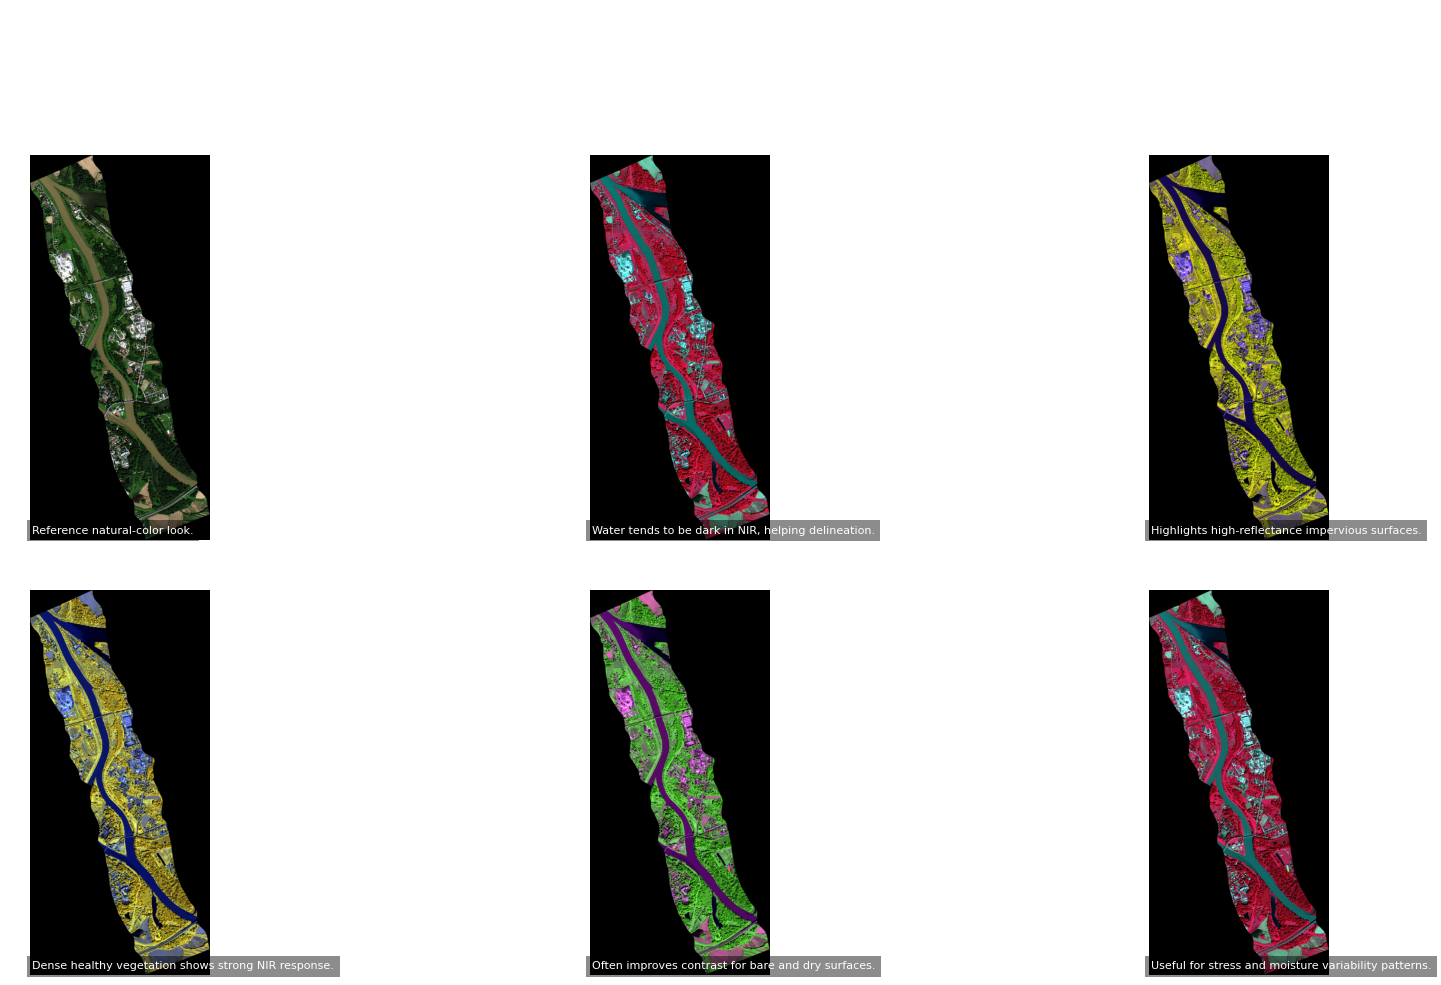

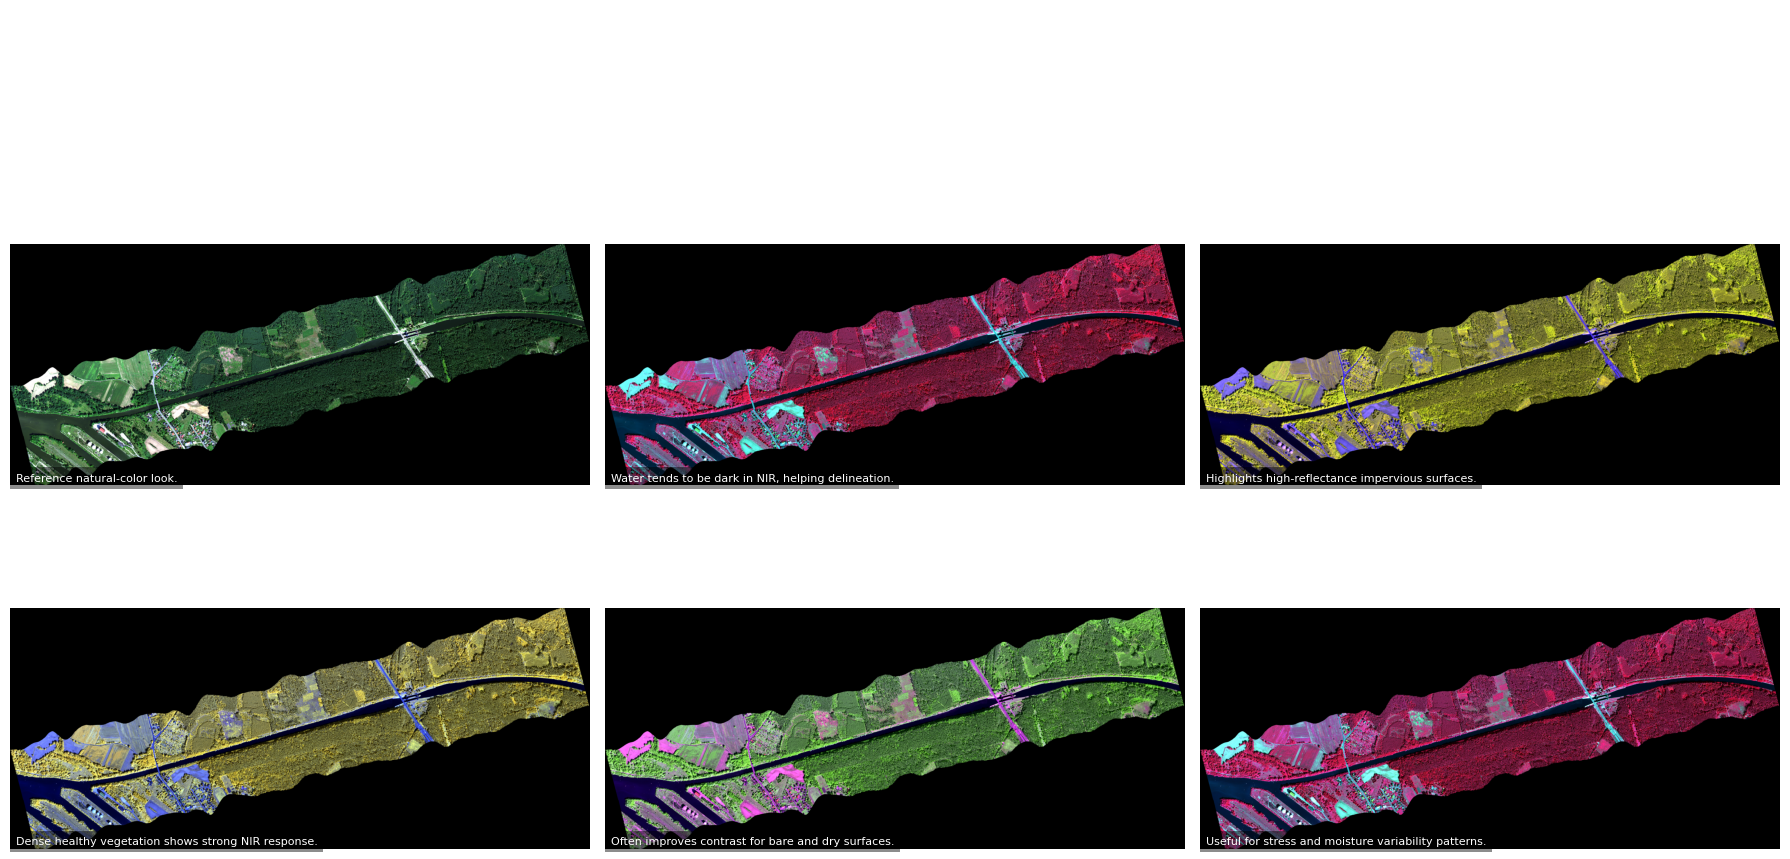

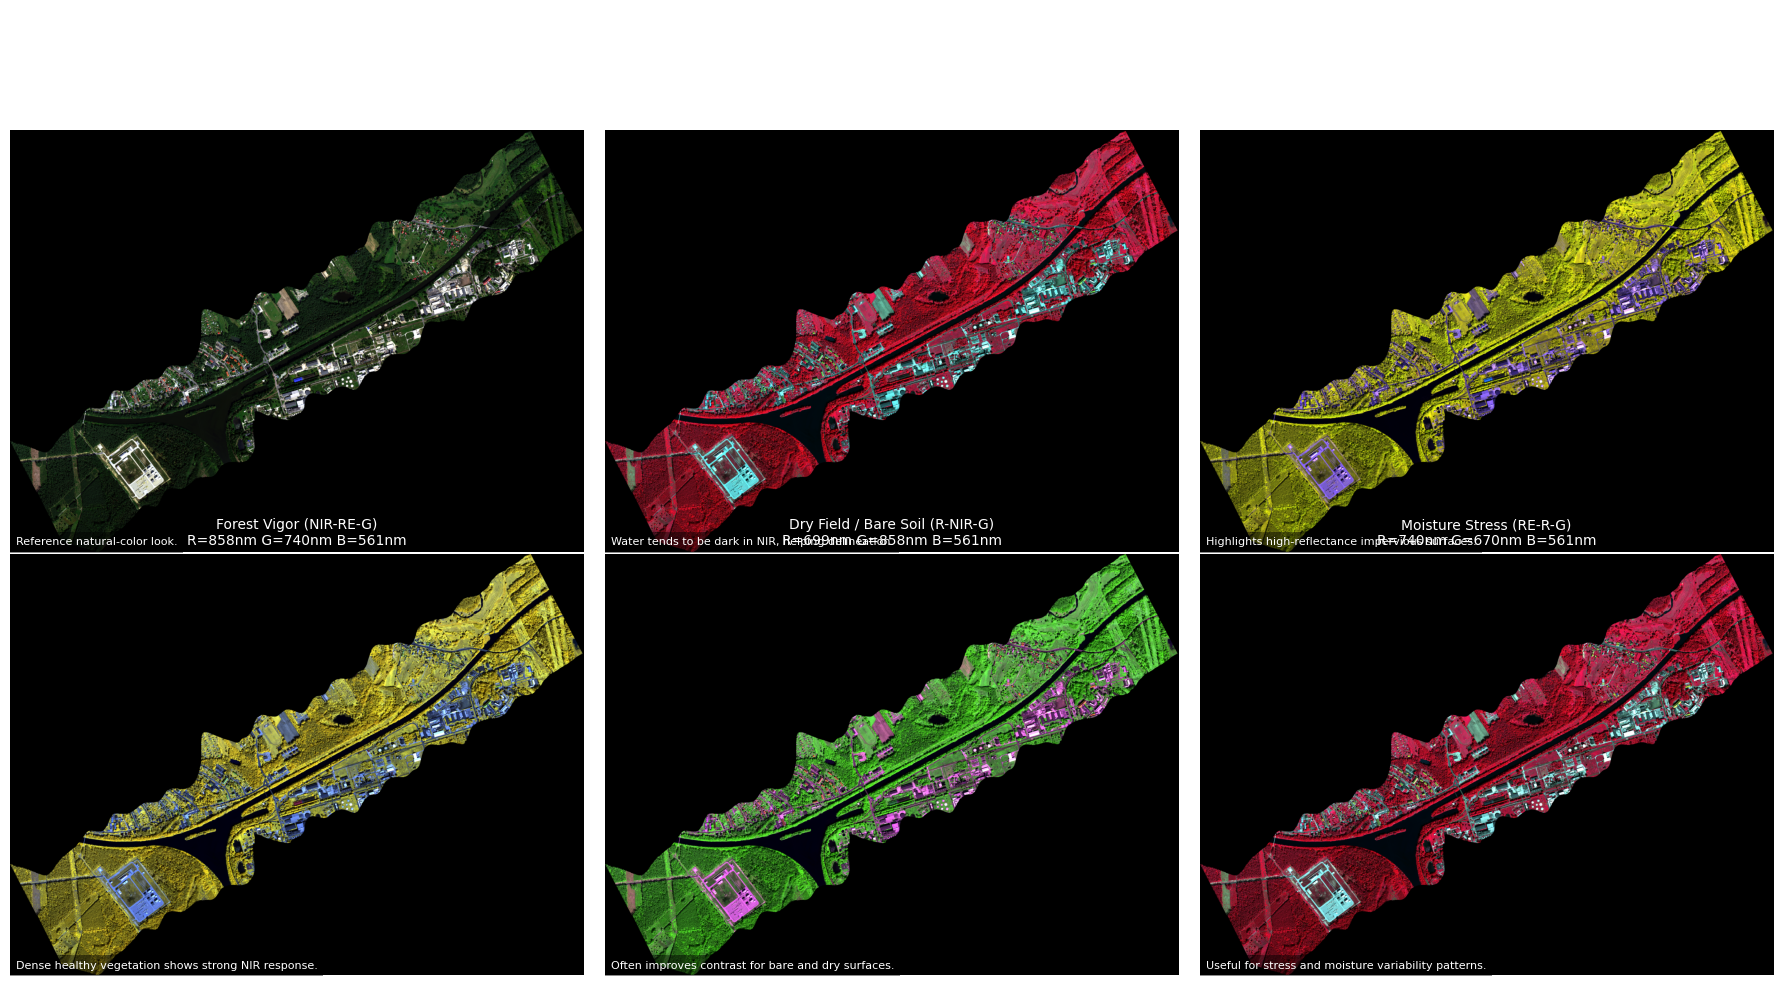

In [23]:
# Target composite definitions: (R_nm, G_nm, B_nm)
COMPOSITES = [
    ('RGB', (650, 560, 470)),
    ('Water', (860, 660, 560)),
    ('Urban', (740, 860, 490)),
    ('Forest', (860, 740, 560)),
    ('Soil', (700, 860, 560)),
    ('Stress', (740, 670, 560)),
]

for hdr in HDR_FILES:
    img = envi.open(str(hdr))
    wavelengths = parse_wavelengths(img.metadata)
    ignore_value = get_ignore_value(img.metadata)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for ax, (label, (r_nm, g_nm, b_nm)) in zip(axes.ravel(), COMPOSITES):
        indices = [
            nearest_band_index(wavelengths, r_nm, img.nbands),
            nearest_band_index(wavelengths, g_nm, img.nbands),
            nearest_band_index(wavelengths, b_nm, img.nbands),
        ]
        ax.imshow(compose_rgb(img, indices, ignore_value=ignore_value))
        ax.set_title(label, fontsize=11)
        ax.axis('off')

    fig.suptitle(hdr.name, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# Calculate water quality indices

This section computes three **hyperspectral proxy indices** for water S over the airborne cubes.

- **Chl-a proxy**: `NDCI = (R705 - R665) / (R705 + R665)`
- **DOC proxy**: green-blue contrast `(R560 - R443) / (R560 + R443)`
- **Turbidity proxy**: red-green contrast `(R665 - R560) / (R665 + R560)`

The maps are shown only for **water-like pixels**, detected here with a simple spectral mask `R560 > R865`.
These outputs should be treated as **relative indicators / proxies**, not calibrated concentrations in physical units.


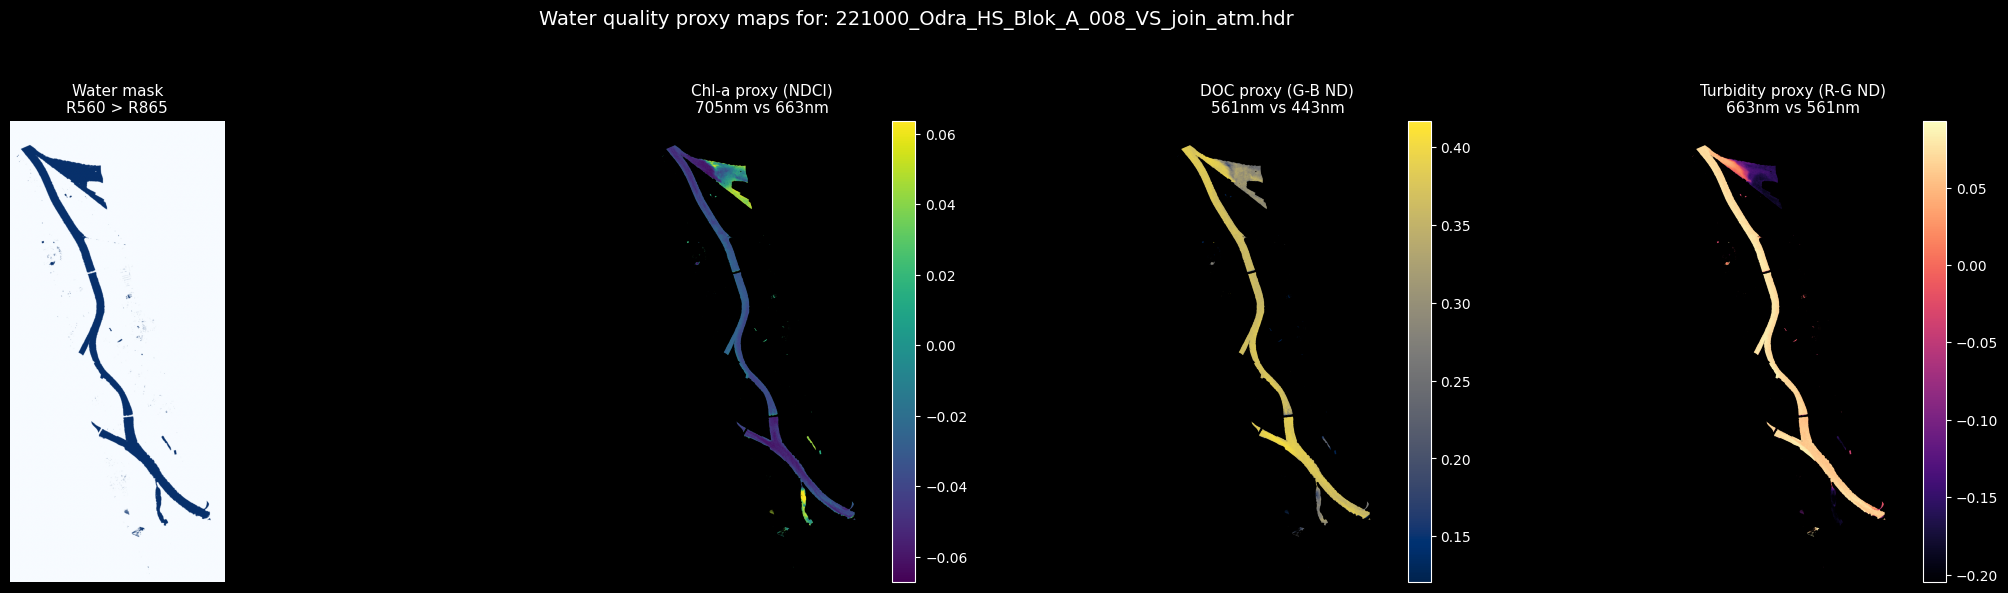

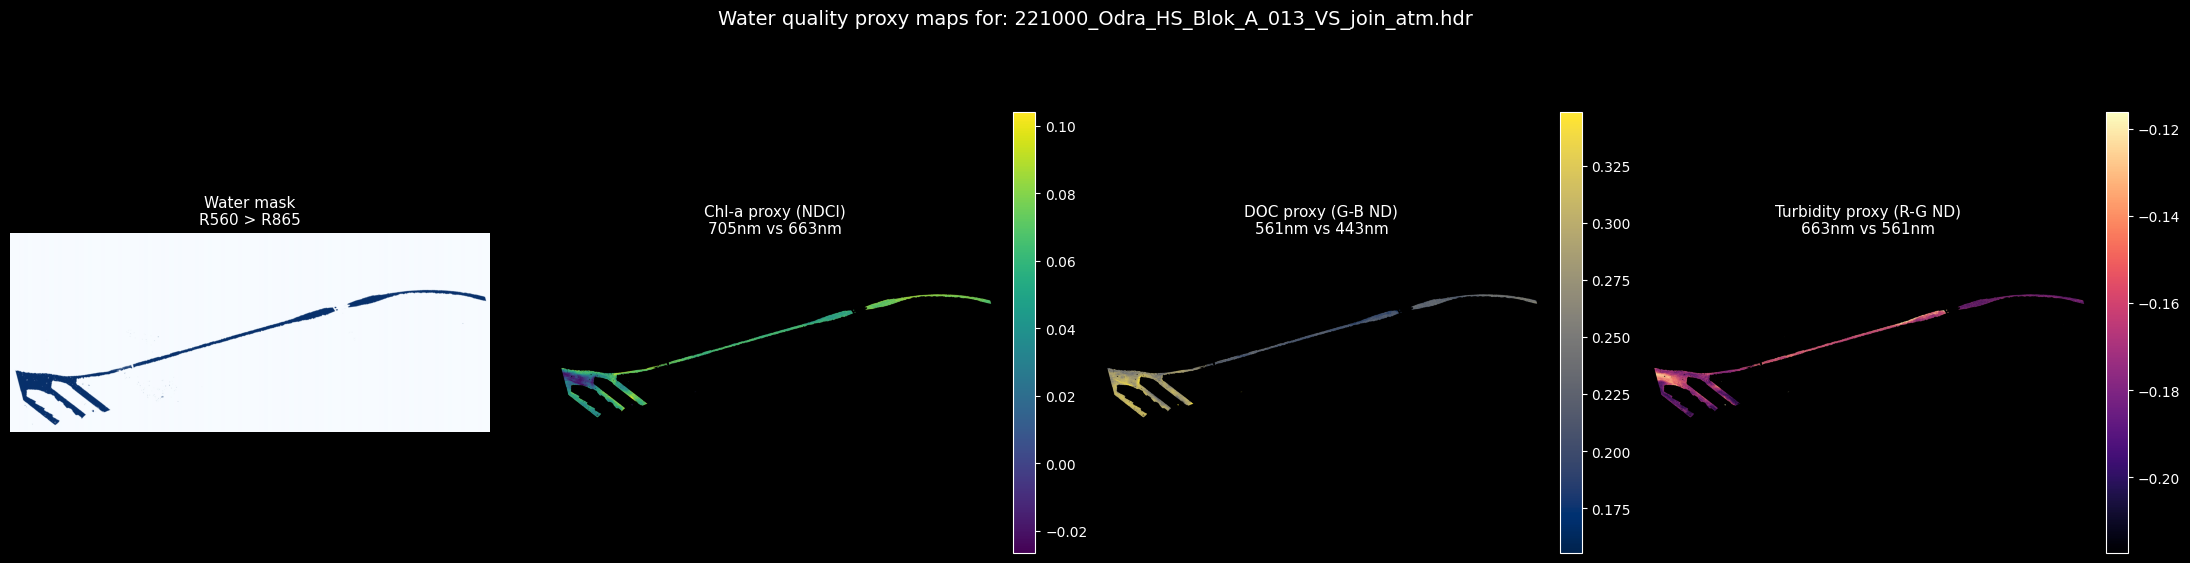

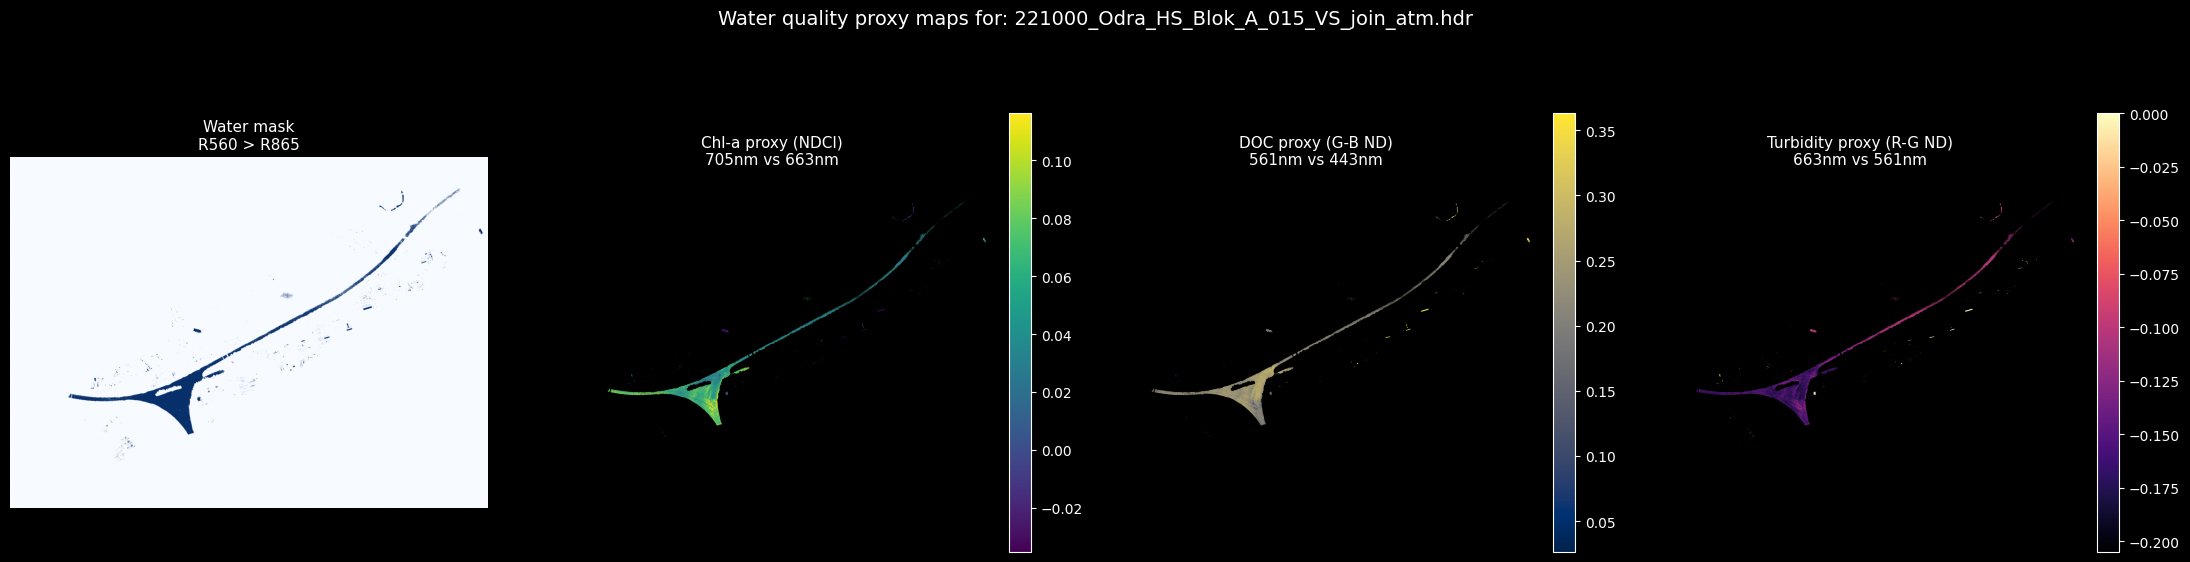

In [24]:
def read_band(img, wavelengths, target_nm, ignore_value=None, scale=10000.0):
    idx = nearest_band_index(wavelengths, target_nm, img.nbands)
    band = img.read_band(idx).astype(np.float32)
    if ignore_value is not None:
        band[band == ignore_value] = np.nan
    band[band < 0] = np.nan
    return band / scale


def nd(a, b):
    return np.divide(a - b, a + b, out=np.full_like(a, np.nan), where=np.abs(a + b) > 1e-6)


INDEX_SPECS = [
    ('Mask', None, None, 'Blues'),
    ('Chl-a', 705, 665, 'viridis'),
    ('DOC', 560, 443, 'cividis'),
    ('Turbidity', 665, 560, 'magma'),
]

for hdr in HDR_FILES:
    img = envi.open(str(hdr))
    meta = img.metadata
    wavelengths = parse_wavelengths(meta)
    ignore_value = get_ignore_value(meta)
    scale = float(meta.get('reflectance scale factor', 10000.0))

    bands = {nm: read_band(img, wavelengths, nm, ignore_value, scale) for nm in {443, 560, 665, 705, 865}}
    water_mask = np.isfinite(bands[560]) & np.isfinite(bands[865]) & (bands[560] > bands[865])

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    axes[0].imshow(water_mask, cmap='Blues')
    axes[0].set_title('Mask', fontsize=11)
    axes[0].axis('off')

    for ax, (label, hi_nm, lo_nm, cmap) in zip(axes[1:], INDEX_SPECS[1:]):
        index_map = nd(bands[hi_nm], bands[lo_nm])
        index_map[~water_mask] = np.nan
        finite = np.isfinite(index_map)
        vmin, vmax = np.nanpercentile(index_map[finite], [2, 98]) if finite.any() else (0.0, 1.0)
        im = ax.imshow(index_map, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(label, fontsize=11)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(hdr.name, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


## Download Sentinel-2 data and compare coverage

The airborne bbox is derived directly from each ENVI header. For every file, the notebook downloads matching Sentinel-2 L2A assets
(`visual`, `B02`, `B03`, `B04`, `B05`, `B08`) and shows:

1. airborne RGB,
2. Sentinel-2 scene with the AOI marked in red,
3. Sentinel-2 crop for the AOI.

Set `SENTINEL_DATE_RANGE` before running.


In [47]:
import planetary_computer
import pystac_client
import rasterio
from matplotlib.patches import Rectangle
from pyproj import CRS, Transformer
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT
from rasterio.windows import from_bounds

CATALOG_URL = 'https://planetarycomputer.microsoft.com/api/stac/v1'
SENTINEL_COLLECTION = 'sentinel-2-l2a'
SENTINEL_DATE_RANGE = '2022-01-01/2022-12-31'
MAX_CLOUD_COVER = 20
SEARCH_LIMIT = 12
PREVIEW_MAX_SIZE = 1200
SENTINEL_ASSETS = {
    'visual': 'visual',
    'blue': 'B02',
    'green': 'B03',
    'red': 'B04',
    'red_edge': 'B05',
    'nir': 'B08',
}

catalog = pystac_client.Client.open(CATALOG_URL, modifier=planetary_computer.sign_inplace)


def meta_as_text(value):
    if isinstance(value, (list, tuple)):
        return ', '.join(str(part).strip() for part in value if str(part).strip())
    return str(value).strip()


def meta_as_int(value):
    return int(float(meta_as_text(value)))


def meta_as_float(value):
    return float(meta_as_text(value))


def parse_default_bands(value):
    if value is None:
        return [74, 45, 18]
    parts = value if isinstance(value, (list, tuple)) else meta_as_text(value).strip('{}').split(',')
    bands = [int(float(part)) - 1 for part in parts[:3]]
    return bands if len(bands) == 3 else [74, 45, 18]


def parse_map_info(meta):
    raw = meta.get('map info')
    parts = raw if isinstance(raw, (list, tuple)) else str(raw).strip().strip('{}').split(',')
    parts = [str(part).strip() for part in parts]
    return {
        'x_ul': meta_as_float(parts[3]),
        'y_ul': meta_as_float(parts[4]),
        'pixel_width': meta_as_float(parts[5]),
        'pixel_height': meta_as_float(parts[6]),
    }


def envi_bounds(meta):
    info = parse_map_info(meta)
    samples = meta_as_int(meta['samples'])
    lines = meta_as_int(meta['lines'])
    min_x = info['x_ul'] - 0.5 * info['pixel_width']
    max_x = min_x + samples * info['pixel_width']
    max_y = info['y_ul'] + 0.5 * info['pixel_height']
    min_y = max_y - lines * info['pixel_height']
    return (min_x, min_y, max_x, max_y)


def lonlat_bounds(bounds, src_crs):
    xs = [bounds[0], bounds[0], bounds[2], bounds[2]]
    ys = [bounds[1], bounds[3], bounds[1], bounds[3]]
    lon, lat = Transformer.from_crs(src_crs, 'EPSG:4326', always_xy=True).transform(xs, ys)
    return (min(lon), min(lat), max(lon), max(lat))


def read_airborne_rgb(hdr):
    img = envi.open(str(hdr))
    rgb = compose_rgb(img, parse_default_bands(img.metadata.get('default bands')), get_ignore_value(img.metadata))
    return img.metadata, rgb


def read_sentinel_bands(item, bbox_lonlat):
    bands = {}
    with rasterio.open(item.assets[SENTINEL_ASSETS['red']].href) as ref_src:
        ref_bounds = Transformer.from_crs('EPSG:4326', ref_src.crs, always_xy=True).transform_bounds(*map(float, bbox_lonlat))
        ref_window = from_bounds(*ref_bounds, ref_src.transform).round_offsets().round_lengths()
        ref_transform = rasterio.windows.transform(ref_window, ref_src.transform)
        ref_height = int(ref_window.height)
        ref_width = int(ref_window.width)

        for label in ['blue', 'green', 'red', 'red_edge', 'nir']:
            asset_name = SENTINEL_ASSETS[label]
            with rasterio.open(item.assets[asset_name].href) as src:
                with WarpedVRT(
                    src,
                    crs=ref_src.crs,
                    transform=ref_transform,
                    height=ref_height,
                    width=ref_width,
                    resampling=Resampling.bilinear,
                ) as vrt:
                    bands[label] = vrt.read(1)
    return bands


def read_visual_products(item, bbox_lonlat):
    with rasterio.open(item.assets['visual'].href) as src:
        scale = max(src.width / PREVIEW_MAX_SIZE, src.height / PREVIEW_MAX_SIZE, 1)
        out_height = max(1, int(round(src.height / scale)))
        out_width = max(1, int(round(src.width / scale)))
        preview = src.read([1, 2, 3], out_shape=(3, out_height, out_width), resampling=Resampling.bilinear).astype(np.float32)
        preview = np.transpose(preview, (1, 2, 0)) / 255.0
        left, bottom, right, top = Transformer.from_crs('EPSG:4326', src.crs, always_xy=True).transform_bounds(*map(float, bbox_lonlat))
        window = from_bounds(left, bottom, right, top, src.transform).round_offsets().round_lengths()
        zoom = src.read([1, 2, 3], window=window, boundless=True).astype(np.float32)
        zoom = np.transpose(zoom, (1, 2, 0)) / 255.0
        row_min, col_min = src.index(left, top)
        row_max, col_max = src.index(right, bottom)
        rect = {
            'x': min(col_min, col_max) * out_width / src.width,
            'y': min(row_min, row_max) * out_height / src.height,
            'width': abs(col_max - col_min) * out_width / src.width,
            'height': abs(row_max - row_min) * out_height / src.height,
        }
        return np.clip(preview, 0, 1), rect, np.clip(zoom, 0, 1)


def select_best_item(items):
    return sorted(
        items,
        key=lambda item: (
            float(item.properties.get('eo:cloud_cover', 100.0) or 100.0),
            -(item.datetime.timestamp() if item.datetime else 0.0),
        ),
    )[0]


221000_Odra_HS_Blok_A_008_VS_join_atm.hdr: S2B_MSIL2A_20220719T095559_R122_T33UYR_20220719T221254 | cloud=0.000409
Bands: blue:(439, 219), green:(439, 219), red:(439, 219), red_edge:(439, 219), nir:(439, 219)


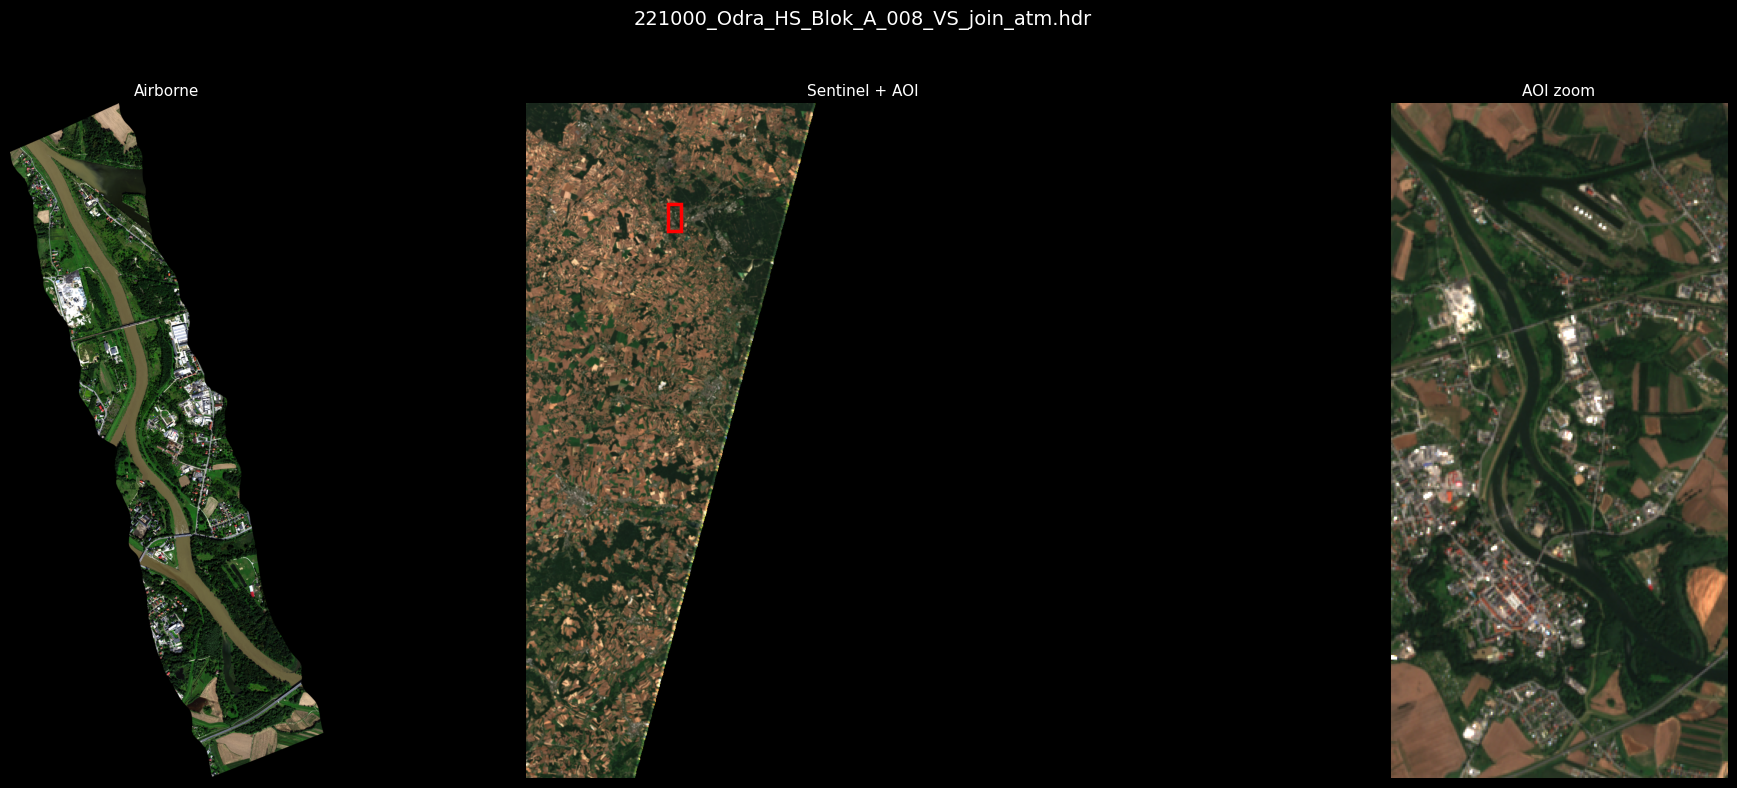

221000_Odra_HS_Blok_A_013_VS_join_atm.hdr: S2B_MSIL2A_20220719T095559_R122_T33UYR_20220719T221254 | cloud=0.000409
Bands: blue:(199, 440), green:(199, 440), red:(199, 440), red_edge:(199, 440), nir:(199, 440)


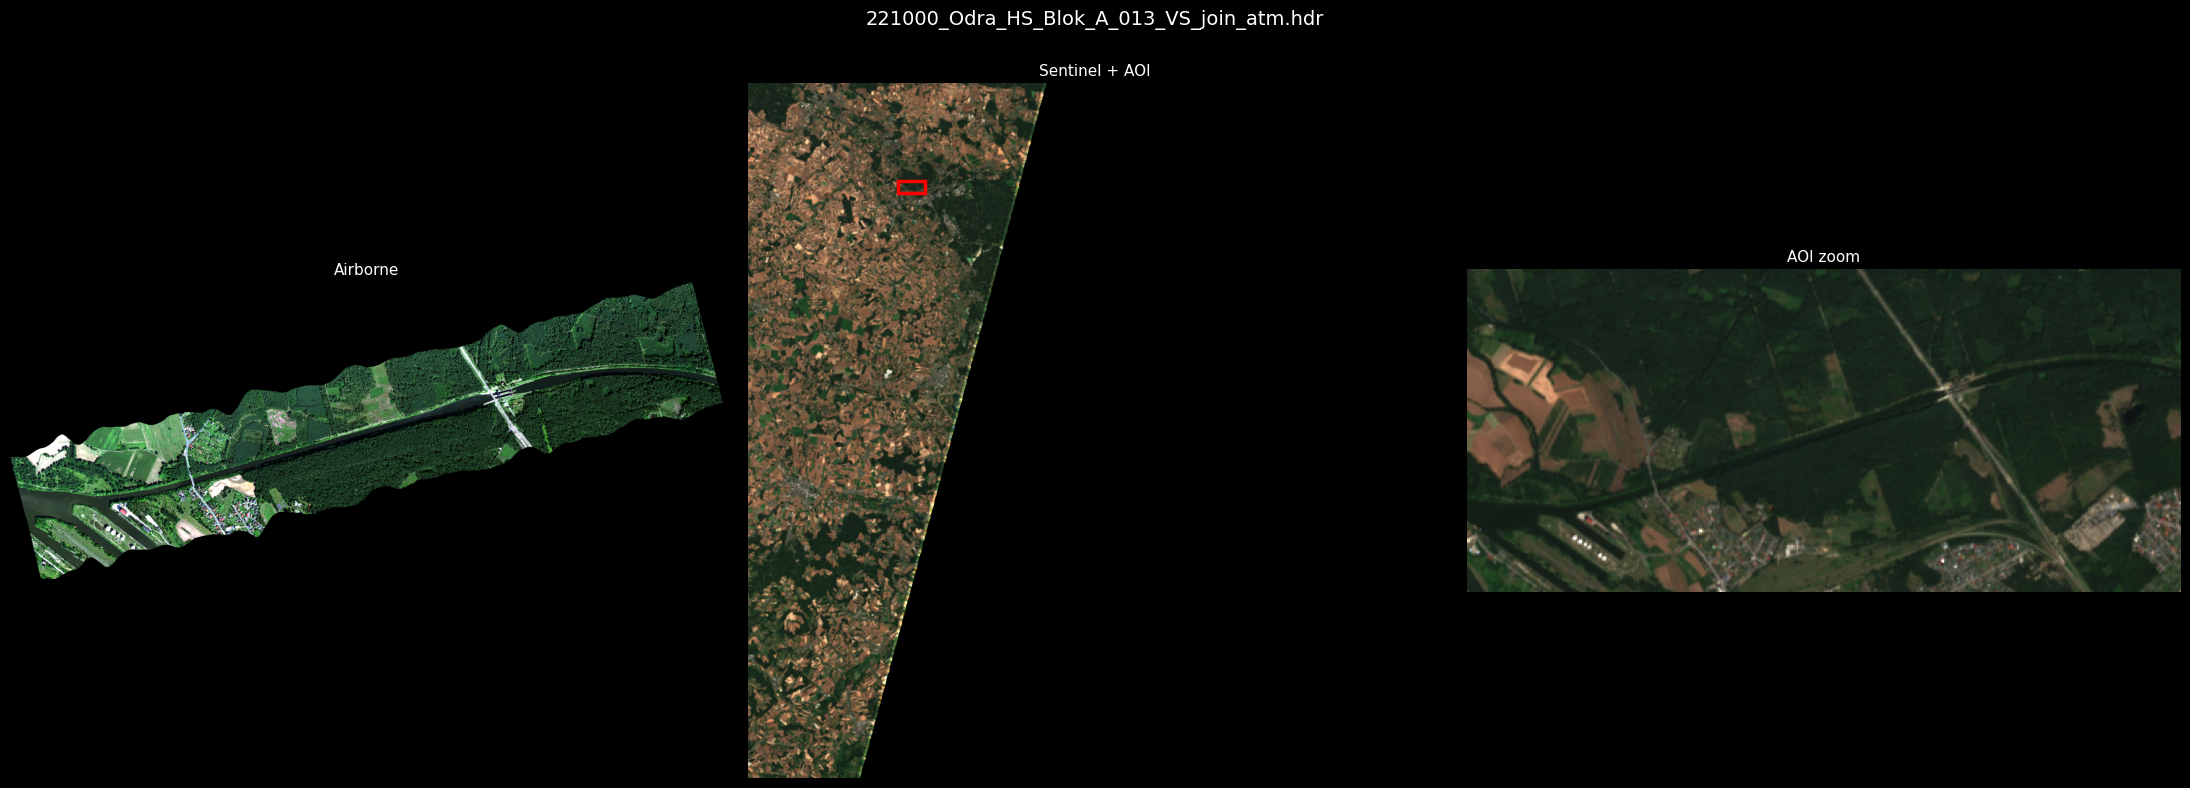

221000_Odra_HS_Blok_A_015_VS_join_atm.hdr: S2B_MSIL2A_20220719T095559_R122_T33UYR_20220719T221254 | cloud=0.000409
Bands: blue:(302, 400), green:(302, 400), red:(302, 400), red_edge:(302, 400), nir:(302, 400)


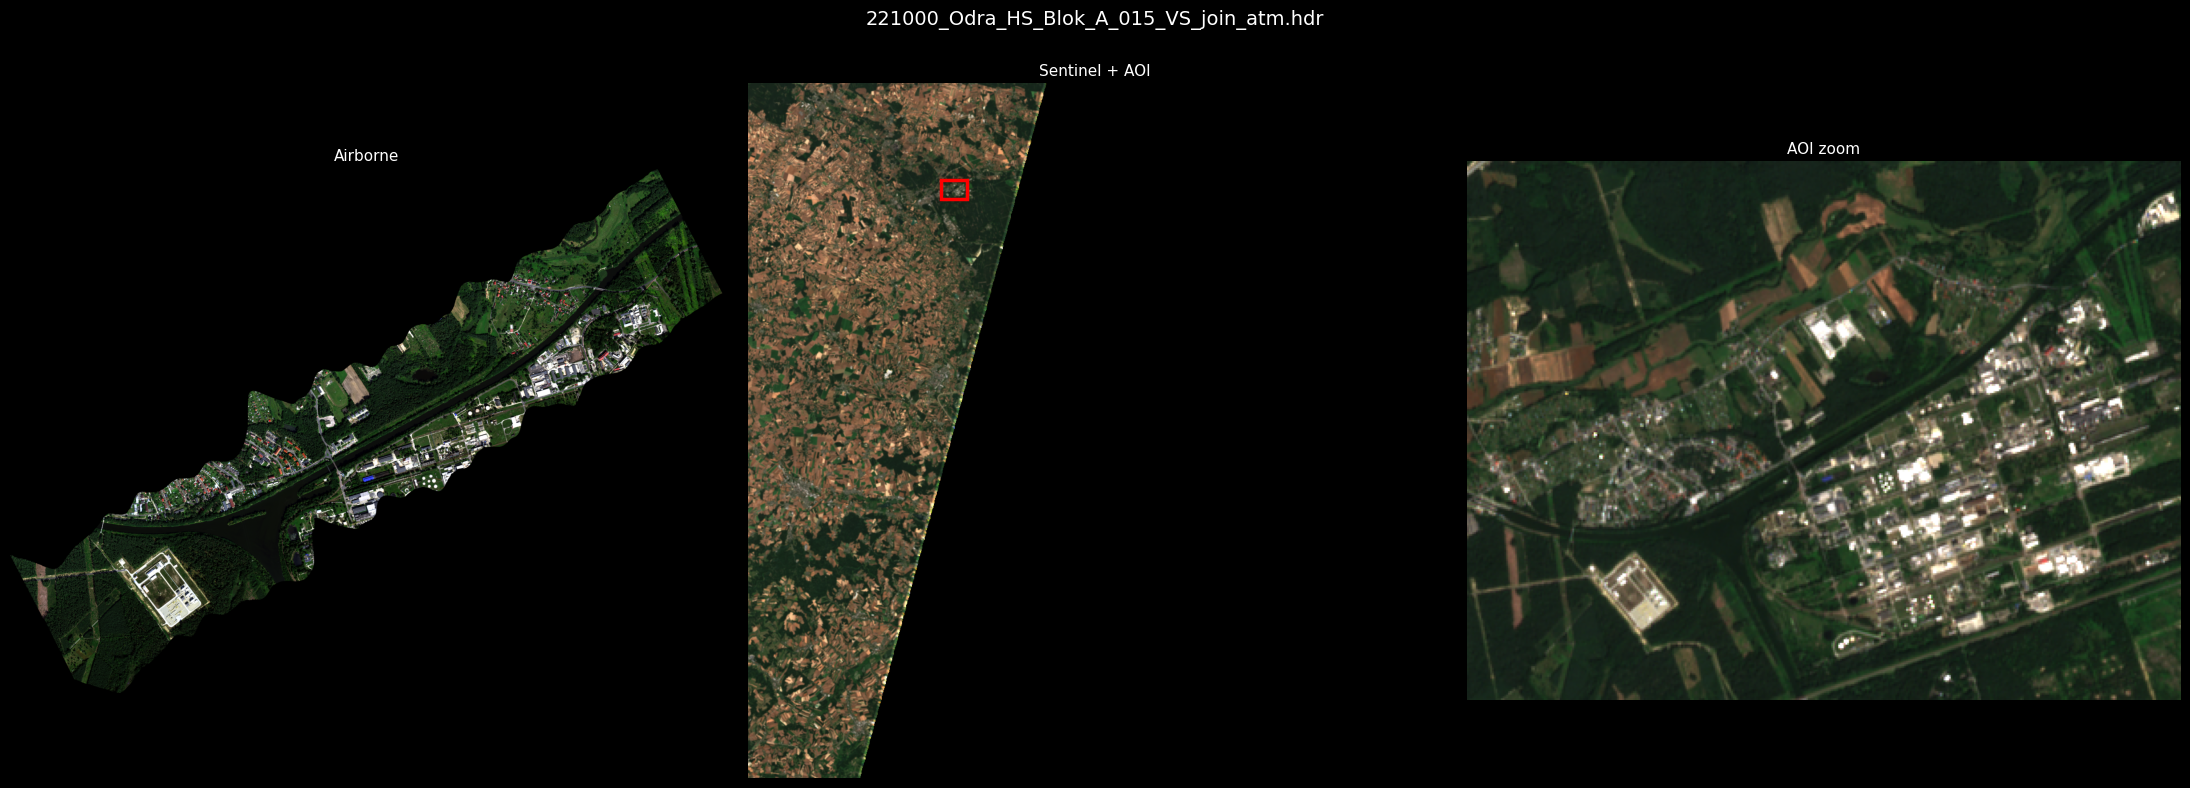

In [48]:
for hdr in HDR_FILES:
    meta, airborne_rgb = read_airborne_rgb(hdr)
    src_crs = CRS.from_wkt(meta_as_text(meta['coordinate system string']))
    bbox_lonlat = lonlat_bounds(envi_bounds(meta), src_crs)
    items = list(catalog.search(
        collections=[SENTINEL_COLLECTION],
        bbox=bbox_lonlat,
        datetime=SENTINEL_DATE_RANGE,
        query={'eo:cloud_cover': {'lt': MAX_CLOUD_COVER}},
        limit=SEARCH_LIMIT,
    ).items())
    if not items:
        raise RuntimeError(f'No Sentinel-2 items found for {hdr.name}.')

    item = select_best_item(items)
    sentinel_bands = read_sentinel_bands(item, bbox_lonlat)
    visual_preview, rect, visual_zoom = read_visual_products(item, bbox_lonlat)

    print(f'{hdr.name}: {item.id} | cloud={item.properties.get("eo:cloud_cover", "n/a")}')
    print('Bands:', ', '.join(f'{name}:{tuple(int(v) for v in sentinel_bands[name].shape)}' for name in sentinel_bands))

    fig, axes = plt.subplots(1, 3, figsize=(22, 8))
    axes[0].imshow(airborne_rgb)
    axes[0].set_title('Airborne', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(visual_preview)
    axes[1].add_patch(Rectangle((rect['x'], rect['y']), rect['width'], rect['height'], fill=False, edgecolor='red', linewidth=2.5))
    axes[1].set_title('Sentinel + AOI', fontsize=11)
    axes[1].axis('off')

    axes[2].imshow(visual_zoom)
    axes[2].set_title('AOI zoom', fontsize=11)
    axes[2].axis('off')

    fig.suptitle(hdr.name, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


## Calculate water quality indices for Sentinel-2

This section uses the downloaded Sentinel-2 bands to compute the same three normalized-difference proxies:

- Chl-a: `(B05 - B04) / (B05 + B04)`
- DOC: `(B03 - B02) / (B03 + B02)`
- Turbidity: `(B04 - B03) / (B04 + B03)`

The maps are shown only for water-like pixels. The mask below is looser than the earlier `green > nir` rule,
because Sentinel-2 water is coarser and the stricter test was removing too much of the river.


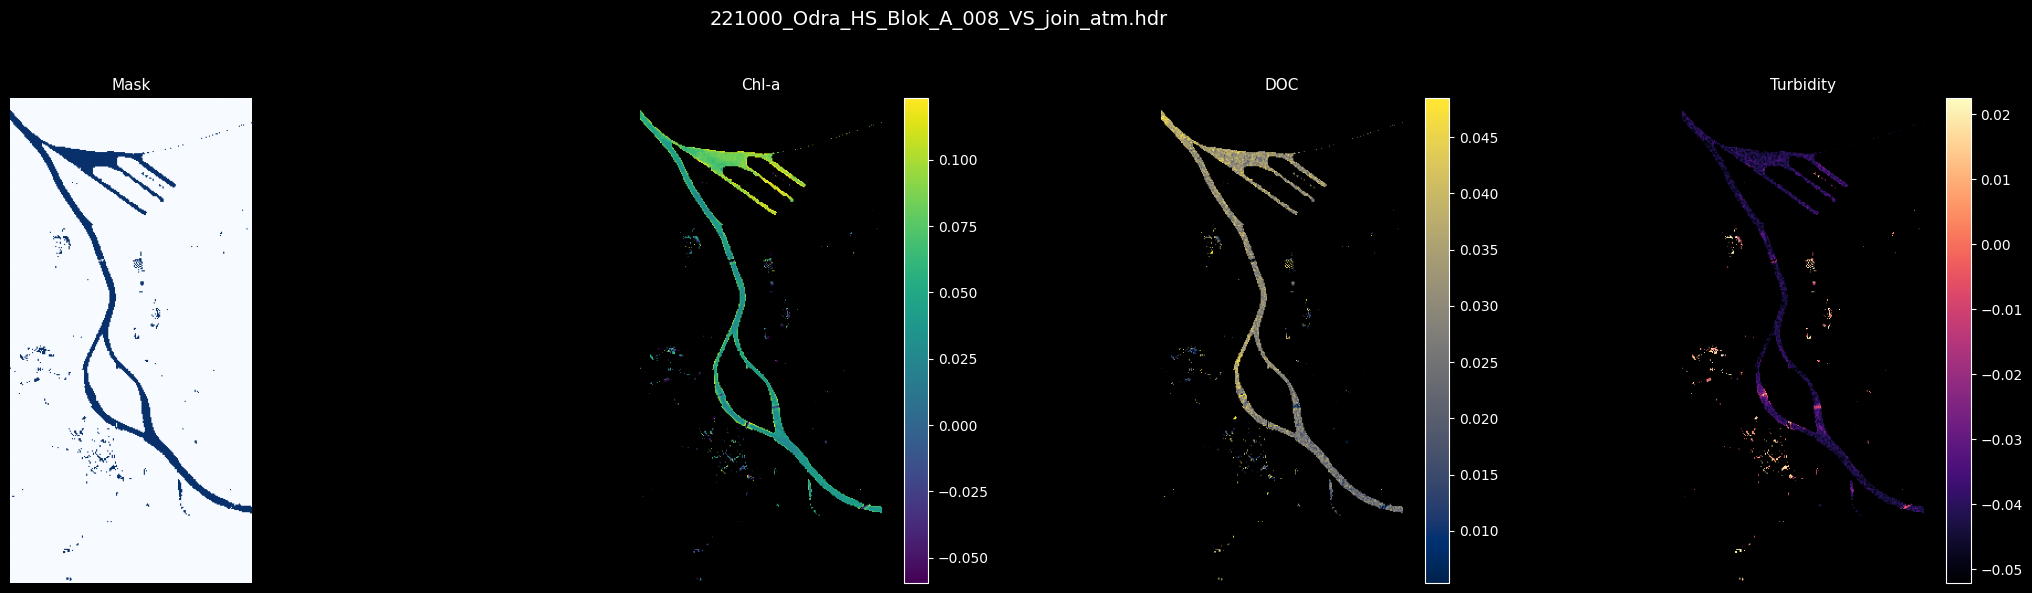

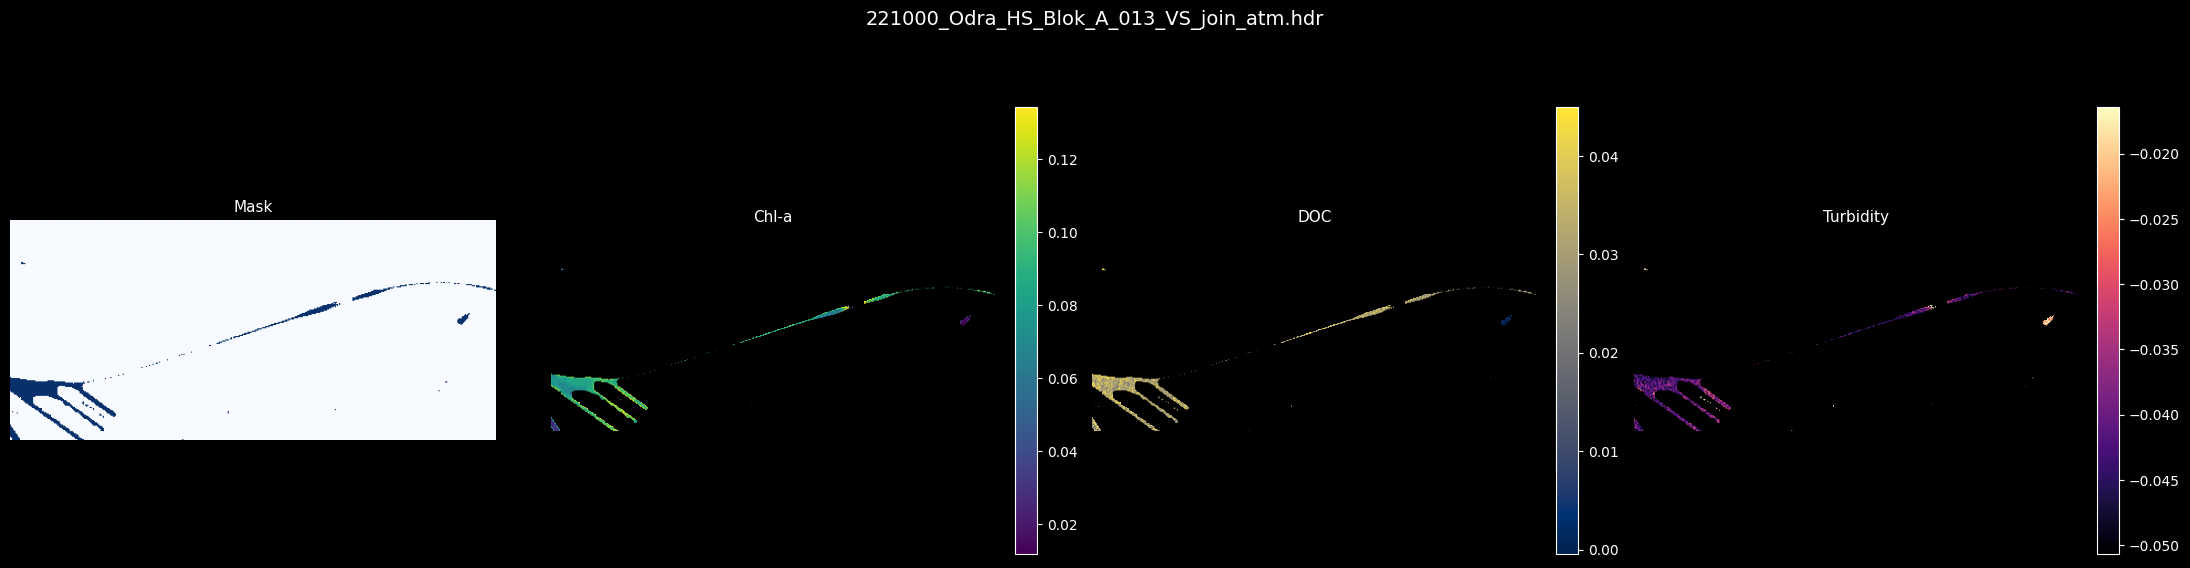

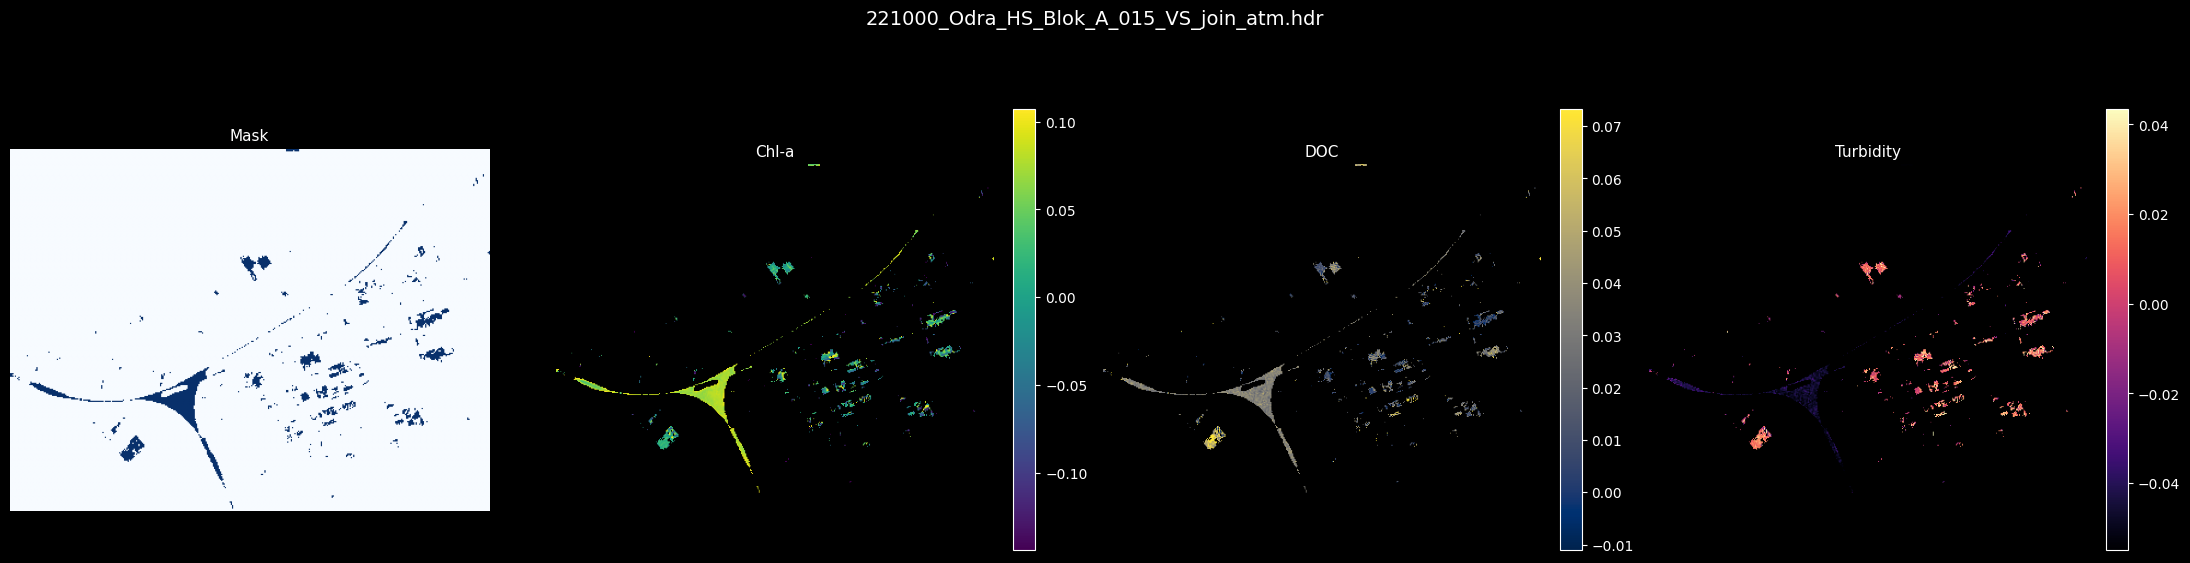

In [54]:
for hdr in HDR_FILES:
    meta, _ = read_airborne_rgb(hdr)
    src_crs = CRS.from_wkt(meta_as_text(meta['coordinate system string']))
    bbox_lonlat = lonlat_bounds(envi_bounds(meta), src_crs)
    items = list(catalog.search(
        collections=[SENTINEL_COLLECTION],
        bbox=bbox_lonlat,
        datetime=SENTINEL_DATE_RANGE,
        query={'eo:cloud_cover': {'lt': MAX_CLOUD_COVER}},
        limit=SEARCH_LIMIT,
    ).items())
    if not items:
        raise RuntimeError(f'No Sentinel-2 items found for {hdr.name}.')

    item = select_best_item(items)
    bands = read_sentinel_bands(item, bbox_lonlat)
    blue = bands['blue'].astype(np.float32) / 10000.0
    green = bands['green'].astype(np.float32) / 10000.0
    red = bands['red'].astype(np.float32) / 10000.0
    red_edge = bands['red_edge'].astype(np.float32) / 10000.0
    nir = bands['nir'].astype(np.float32) / 10000.0

    # Sentinel water mask: use a permissive union of two simple rules.
    # This is where the water detection is relaxed compared with the earlier strict mask.
    ndwi = nd(green, nir)
    valid = np.isfinite(blue) & np.isfinite(green) & np.isfinite(red) & np.isfinite(red_edge) & np.isfinite(nir)
    water_mask = valid & (green > nir * 0.9)

    chl = nd(red_edge, red)
    doc = nd(green, blue)
    turbidity = nd(red, green)

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    axes[0].imshow(water_mask, cmap='Blues')
    axes[0].set_title('Mask', fontsize=11)
    axes[0].axis('off')

    for ax, label, index_map, cmap in [
        (axes[1], 'Chl-a', chl, 'viridis'),
        (axes[2], 'DOC', doc, 'cividis'),
        (axes[3], 'Turbidity', turbidity, 'magma'),
    ]:
        index_map = index_map.copy()
        index_map[~water_mask] = np.nan
        finite = np.isfinite(index_map)
        vmin, vmax = np.nanpercentile(index_map[finite], [2, 98]) if finite.any() else (0.0, 1.0)
        im = ax.imshow(index_map, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(label, fontsize=11)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(hdr.name, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


The airborne data shows the same overall spatial pattern of water and elevated index zones as Sentinel-2, but it captures narrow channels, shorelines, and local index variability much more clearly. Sentinel-2 provides a smoother, more simplified view of the same phenomena, so it works well for assessing general trends across the whole water body, but it loses the fine detail visible in the airborne data.